Импорты

In [5]:
from collections import Counter

from tqdm import tqdm
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score

import numpy as np
import pandas as pd
import json
import re
import matplotlib.pyplot as plt
import pymorphy3
import gensim

Вывод JSON в DataFrame

In [6]:
responses = []
with open('banki_responses.json', 'r') as thefile:
    for row in tqdm(thefile):
        resp = json.loads(row)
        responses.append(resp)

df = pd.DataFrame(responses)

201030it [00:09, 20687.32it/s]


In [24]:
df.head(10)

,city,rating_not_checked,title,num_comments,bank_license,author,bank_name,datetime,text,rating_grade
0,г. Воронеж,True,Ипотека на 5+,0,лицензия № 1623,e.novikova,ВТБ 24,2015-06-08 11:06:56,Здравствуйте! Хотелось бы выразить благодарно...,5.0
1,г. Казань,True,ЗВОНКИ СОСЕДЯМ,0,лицензия № 2289,KZN\Vorontsova_NA,Русский Стандарт,2015-06-06 18:17:52,Уважаемые представители департамента по работе...,2.0
2,г. Санкт-Петербург,True,Ложная информация!!!!,0,лицензия № 2307,Evgenia15,Союз,2015-06-07 19:08:33,Здравствуйте. Столкнулась с такой ситуацией. в...,2.0
3,г. Москва,True,Банкомат не зачислил деньги на счет,1,лицензия № 2557,dolgov.work,Ситибанк,2015-06-07 19:22:00,1 июня 2015 в Москве в отделении по адресу Смо...,1.0
4,г. Волгоград,True,Невозможно закрыть карту 2(два)!!!,0,лицензия № 3354,copLine,Ренессанс Кредит,2015-06-08 14:54:55,История очень долгая! Пришел я в банк (это раз...,1.0
5,г. Москва,False,Жалоба,0,лицензия № 2562,uhnov1,Бинбанк,2015-06-08 12:50:54,Добрый день! Я не являюсь клиентом банка и пор...,NaN
6,г. Новосибирск,False,Не могу пользоваться услугой Сбербанк он-лайн,0,лицензия № 1481,Foryou,Сбербанк России,2015-06-08 11:09:57,Доброго дня! Являюсь держателем зарплатной кар...,NaN
7,г. Краснодар,True,Информирование по электронной почте.,0,лицензия № 2518,secofr,Кубань Кредит,2015-06-06 13:10:53,Здравствуйте. Есть у меня VISA Electron от Куб...,3.0
8,г. Москва,True,Выплаты по Транспортному,4,лицензия № 1623,Бафомет,ВТБ 24,2015-06-06 13:40:55,"Послеотзыва лицензии у Транспортного, с нетерп...",2.0
9,г. Москва,True,Большая блаодарность!,0,лицензия № 1623,кристина1987,ВТБ 24,2015-06-08 14:43:51,Хочу поблагодарить Надежду из отдела по ипотеч...,5.0


Обработка датасета

In [ ]:
# for i_city in df['city'].unique():
#     print(i_city)
# Присутствуют такие дубликаты как г. Дзержинск и г. Дзержинск (Нижегородская обл.)

In [ ]:
df['city'] = df['city'].apply(lambda x: re.sub(r"^г\.\s*|\s*\(.*?\)", "", x).lower() if x else x)
# Обработал города. г. Дзержинск (Нижегородская обл.) -> дзержинск

In [ ]:
print(f"Число лицензий банков: {df['bank_license'].nunique()}, \nЧисло банков: {df['bank_name'].nunique()}")
# У одного банка может быть несколько лицензий, но никак ни у нескольких банков одна лицензия

In [ ]:
df[df['bank_license'].isna()]
# Лицензии не приписывают записям с участием филиала банков. Такие записи не подходят.

In [ ]:
df.dropna(subset=['bank_license'], inplace=True)

In [ ]:
for i_lic in df['bank_license'].unique():
    if df[df['bank_license'] == i_lic]['bank_name'].nunique() > 1:
        print(f'Лицензия: {i_lic}, \nБанки: {df[df["bank_license"] == i_lic]["bank_name"].unique()}\n\n')
#  Нет ни одной лицензии с несколькими банками

In [ ]:
for i_name in df['bank_name'].unique():
    amount = df[df['bank_name'] == i_name]['bank_license'].nunique()
    if amount > 1:
        print(f'Название банка: {i_name}, \nКоличество лицензий: {amount}')
#Только один банк с > 1 лицензией

Анализ количества отзывов в разных городах и на разные банки

In [ ]:
df.groupby('city').count()
# Обнаружил множество мусорных записей. У множества общая черта это +- 1 отзыв

In [ ]:
bank_data_gen = ((i_name, df[df['bank_name'] == i_name]['text'].count()) for i_name in df['bank_name'].unique())
city_data_gen = ((i_city, i_count) for i_city in df['city'].unique() if (i_count:=df[df['city'] == i_city]['text'].count()) > 5)

bank_names, bank_text_count = list(zip(*list(bank_data_gen)))
city_names, city_text_count = list(zip(*list(city_data_gen)))

In [ ]:
city_series = pd.Series(index=city_names, data=city_text_count)
bank_series = pd.Series(index=bank_names, data=bank_text_count)

In [ ]:
print(f'Количество отзывов по банкам: {bank_series}')

In [ ]:
print(f'Количество отзывов по городам: {city_series}')

Построение гистограмм длин отзывов по количеству слов и символов

In [ ]:
text = df['text'].drop_duplicates()
# Для того чтобы не тратить ресурсы на пересчет спама

In [ ]:
words_amount = text.apply(lambda x: len(re.findall(r'\w+', x)))
symbols_amount = text.apply(lambda x: len(x))

In [ ]:
plt.figure(figsize = (10,5))

plt.subplot(121)
plt.hist(words_amount, bins=10)
plt.title('Гистограмма длины в словах')

plt.subplot(122)
plt.hist(symbols_amount, bins=10)
plt.title('Гистограмма длины в символах')

plt.show()

In [ ]:
all_texts = ', '.join(df['text'].values).lower()
# Все отзывы приведенные в нижний регистр и сохраненные в одной строке

Функция для подсчета слов

In [ ]:
def count_words(words_list, n: int):
    counted_words = Counter(words_list)
    return list(zip(*counted_words.most_common(n=n)))

10 самых частых слов

In [ ]:
index, data = count_words(words_list=all_texts.split(), n=10)
pd.Series(index=index, data=data).plot(kind='bar')
plt.show()

10 самых частых слов без стоп-слов

In [ ]:
sw = stopwords.words('russian')
processed_text = re.sub(r'\W+', ' ', all_texts)
processed_text = [word for word in processed_text.split() if word not in sw]

In [ ]:
index, data = count_words(words_list=processed_text, n=10)
pd.Series(index=index, data=data).plot(kind='bar')
plt.show()

10 самых частых лемм

In [ ]:
morph = pymorphy3.MorphAnalyzer()

In [ ]:
normed_text_gen = (morph.parse(word)[0].normal_form for word in processed_text)

In [ ]:
index, data = count_words(words_list=normed_text_gen, n=10)
pd.Series(index=index, data=data).plot(kind='bar')
plt.show()

10 самых частых существительных

In [ ]:
noun_text_gen = (normed_word.normal_form for word in processed_text
                 if (normed_word:=morph.parse(word)[0]).tag.POS == 'NOUN')

In [ ]:
noun_words_counted = Counter(noun_text_gen)

In [ ]:
index, data = list(zip(*noun_words_counted.most_common(n=10)))
pd.Series(index=index, data=data).plot(kind='bar')
plt.show()

Кривые Ципфа и Хипса

In [ ]:
frequencies = np.array(list(dict(sorted(Counter(all_texts.split()).items(), key=lambda x: x[1], reverse=True)).values()))
ranks = np.arange(1, len(frequencies) + 1)

In [ ]:
plt.figure()
plt.loglog(ranks, frequencies, color='red')
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.title("Zipf plot")
plt.show()

In [26]:
unique_words = set()

unique_words_amounts = np.empty(5)
fracs = list(i_frac / 10 for i_frac in range(2, 11, 2))

In [31]:
for index, i_frac in enumerate(fracs):
    cur_piece_text = df['text'].sample(frac=i_frac, random_state=42)
    cur_piece_text = cur_piece_text.apply(lambda i_text: re.sub(r'\W+', ' ', i_text.lower()))

    gen = (unique_words.add(i_word) for i_sentence in cur_piece_text for i_word in i_sentence.split())
    list(gen)

    unique_words_amounts[index] = len(unique_words)

In [33]:
unique_words_amounts = np.concatenate([[unique_words_amounts[0]],
                                     np.diff(unique_words_amounts)])

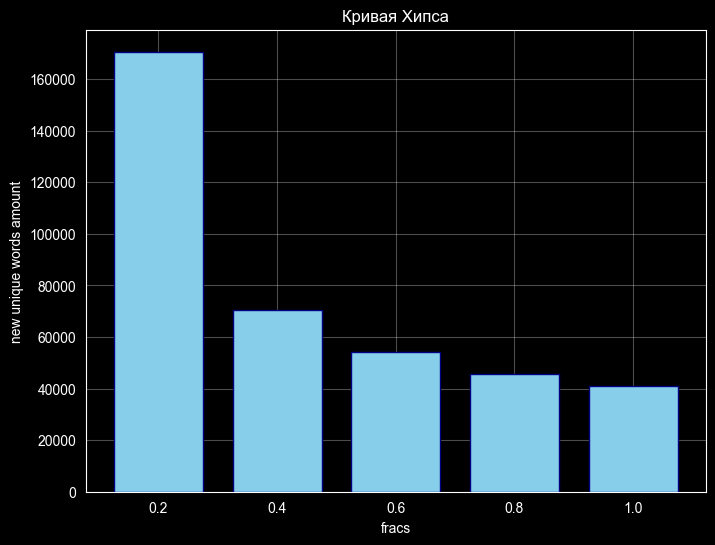

In [45]:
plt.figure(figsize=(8, 6))
plt.bar(fracs, unique_words_amounts, width=0.15, color='skyblue', edgecolor='navy', linewidth=1)
plt.xlabel('fracs')
plt.ylabel('new unique words amount')
plt.title('Кривая Хипса')
plt.grid(True, alpha=0.3)
plt.show()

Частота слов

In [ ]:
print("сотрудник встречается чаще" if noun_words_counted['сотрудник'] > noun_words_counted['клиент'] else "клиент встречается чаще")

In [ ]:
print(f"Слово 'доверие' встречается {noun_words_counted['доверие']} раз\nСлово 'мошенничество' встречается {noun_words_counted['мошенничество']} раз")

Векториация отзывов

In [ ]:
df['processed_text'] = df['text'].apply(lambda x: re.sub(r'\W+', ' ', x.lower()))
df['processed_text'] = df['processed_text'].apply(lambda x: ' '.join([morph.parse(word)[0].normal_form for word in x.split()]))

In [ ]:
tf_idf_vectorizer = TfidfVectorizer(
    stop_words=sw,
    ngram_range=(1, 2),
    max_df=0.8,
    min_df=100,
)
tf_idf_vectorizer.fit(df['processed_text'])

In [ ]:
pos_texts = df[df['rating_grade'] == 5]['processed_text']
neg_texts = df[df['rating_grade'] == 1]['processed_text']

In [ ]:
positive = tf_idf_vectorizer.transform(pos_texts)
negative = tf_idf_vectorizer.transform(neg_texts)

In [ ]:
feature_names = tf_idf_vectorizer.get_feature_names_out()

mean_tfidf_pos = np.asarray(positive.mean(axis=0)).ravel()
mean_tfidf_neg = np.asarray(negative.mean(axis=0)).ravel()

In [ ]:
top_pos = sorted(
    zip(feature_names, mean_tfidf_pos),
    key=lambda x: x[1],
    reverse=True
)

top_neg = sorted(
    zip(feature_names, mean_tfidf_neg),
    key=lambda x: x[1],
    reverse=True
)

In [ ]:
# Ключевые слова для позитивных отзывов
print(top_pos[:3])

In [ ]:
# Ключевые слова для отрицательных отзывов
print(top_neg[:3])

Тематическое моделирование

In [ ]:
all_texts = [[word for word in doc.split() if len(word) > 2 and word not in sw] for doc in df['processed_text']]

In [ ]:
dictionary = gensim.corpora.Dictionary(all_texts)
dictionary.filter_extremes(no_below=200, no_above=0.5)

In [ ]:
corpus = [dictionary.doc2bow(text) for text in all_texts]

In [ ]:
lda_model_5_tops = gensim.models.LdaModel(corpus=corpus,
                                          id2word=dictionary,
                                          num_topics=5,
                                          random_state=42,
                                          passes=10,
                                          alpha='auto')

In [ ]:
for topic_id in range(lda_model_5_tops.num_topics):
    print(f"\nТема {topic_id}")
    print(lda_model_5_tops.print_topic(topic_id))

In [ ]:
# 1 Тема - операционное банковское обслуживания. Сбербанк присутствует потому что это банк, он связан со всеми операциями, банкоматами и т.п.
# 2 Тема - коммуникации банка с клиентом.
# 3 Тема - кредитование. Наблюдается множество кредитной семантики
# 4 Тема - жалобы
# 5 Тема - обслуживание

Классификация текстов

In [ ]:
neg_data = df[df['rating_grade'] == 1][['processed_text', 'rating_grade']].sample(n=5000, random_state=42)
pos_data = df[df['rating_grade'] == 5][['processed_text', 'rating_grade']].sample(n=5000, random_state=42)

clf_data = pd.concat([neg_data, pos_data], ignore_index=True, axis=0)

In [ ]:
x, y = clf_data['processed_text'], clf_data['rating_grade']
y = y.apply(lambda rating: 1 if rating == 5 else 0)

In [ ]:
tf_idf_vectorizer_unigram = TfidfVectorizer(stop_words=sw,
                                            ngram_range=(1, 1),
                                            max_df=0.8,
                                            min_df=100)

tf_idf_vectorizer_bigram = TfidfVectorizer(stop_words=sw,
                                           ngram_range=(2, 2),
                                           max_df=0.8,
                                           min_df=100)

tf_idf_vectorizer_trigram = TfidfVectorizer(stop_words=sw,
                                            ngram_range=(3, 3),
                                            max_df=0.8,
                                            min_df=100)

tf_idf_vectorizer_char = TfidfVectorizer(
    analyzer='char',
    ngram_range=(3, 5),
    min_df=500,
    max_df=0.8,
)

In [ ]:
unigram_test = cross_validate(KNeighborsClassifier(), tf_idf_vectorizer_unigram.fit_transform(x), y, cv=5, scoring=['accuracy', 'f1'])
bigram_test = cross_validate(KNeighborsClassifier(), tf_idf_vectorizer_bigram.fit_transform(x), y, cv=5, scoring=['accuracy', 'f1'])
trigram_test = cross_validate(KNeighborsClassifier(), tf_idf_vectorizer_trigram.fit_transform(x), y, cv=5, scoring=['accuracy', 'f1'])
char_test = cross_validate(KNeighborsClassifier(), tf_idf_vectorizer_char.fit_transform(x), y, cv=5, scoring=['accuracy', 'f1'])

print(f"accuracy при использовании только символьных n-грамм: {char_test['test_accuracy'].mean()}\n"
      f"f1 при использовании только символьных n-грамм: {char_test['test_f1'].mean()}\n\n"
      f"accuracy при использовании только униграмм: {unigram_test['test_accuracy'].mean()}\n"
      f"f1 при использовании только униграмм: {unigram_test['test_f1'].mean()}\n\n"
      f"accuracy при использовании только биграмм: {bigram_test['test_accuracy'].mean()}\n"
      f"f1 при использовании только биграмм: {bigram_test['test_f1'].mean()}\n\n"
      f"accuracy при использовании только триграмм: {trigram_test['test_accuracy'].mean()}\n"
      f"f1 при использовании только триграмм: {trigram_test['test_f1'].mean()}")

Сравнение, как изменяется качество решения задачи при использовании скрытых тем в качестве признаков

1 вариант

In [ ]:
pipeline_svd = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words=sw,
                              ngram_range=(1, 1),
                              max_df=0.8,
                              min_df=100)),
    ('svd', TruncatedSVD(n_components=100, random_state=42)),
    ('clf', KNeighborsClassifier())
])

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
pipeline_svd.fit(x_train, y_train)
y_pred_svd = pipeline_svd.predict(x_test)

In [ ]:
print("Accuracy SVD:", accuracy_score(y_test, y_pred_svd))
print("F1 SVD:", f1_score(y_test, y_pred_svd))

2 вариант

In [ ]:
count_vectorizer = CountVectorizer(
    min_df=100,
    max_df=0.8
)

x_train_count = count_vectorizer.fit_transform(x_train)
x_test_count = count_vectorizer.transform(x_test)

In [ ]:
lda = LatentDirichletAllocation(random_state=42)

X_train_lda = lda.fit_transform(x_train_count)
X_test_lda = lda.transform(x_test_count)

In [ ]:
clf_lda = KNeighborsClassifier()
clf_lda.fit(X_train_lda, y_train)

y_pred_lda = clf_lda.predict(X_test_lda)

In [132]:
print("Accuracy LDA:", accuracy_score(y_test, y_pred_lda))
print("F1 LDA:", f1_score(y_test, y_pred_lda))

Accuracy LDA: 0.89
F1 LDA: 0.888663967611336
